In [3]:
# ==========================================
# AGGLOMERATIVE CLUSTERING - MALL CUSTOMERS
# ==========================================

# 1. IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [6]:
# ==========================================
# 3. SELECT IMPORTANT FEATURES
# ==========================================
# Using Annual Income and Spending Score

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [8]:
# ==========================================
# 4. FEATURE SCALING
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

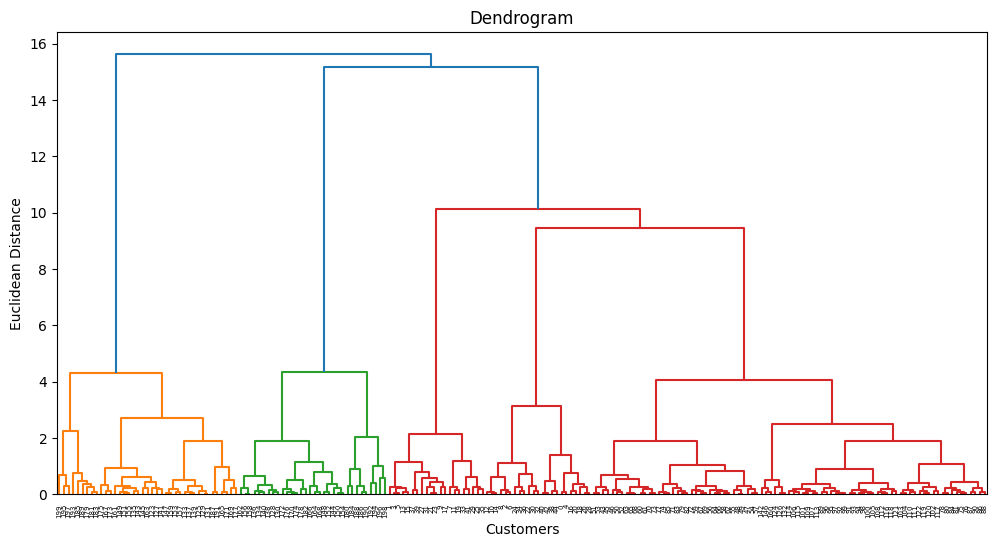

In [9]:
# ==========================================
# 5. CREATE DENDROGRAM
# ==========================================
# Helps identify optimal number of clusters

plt.figure(figsize=(12, 6))

linked = linkage(X_scaled, method='ward')

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [10]:
# ==========================================
# 6. TRAIN AGGLOMERATIVE CLUSTERING MODEL
# ==========================================
# Assume optimal clusters = 3
#largest vertical jump in distance (around Euclidean distance ≈ 15), drawing a horizontal cut line there intersects three main vertical stems. 
#That means the dataset naturally separates into three clusters.

model = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

clusters = model.fit_predict(X_scaled)

In [11]:
# ==========================================
# 7. ADD CLUSTER LABELS TO DATAFRAME
# ==========================================
df['Cluster'] = clusters

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        0  
1        0  
2        0  
3        0  
4        0  


In [12]:
supervised = pd.DataFrame(df)
supervised.to_csv("Agglomerative_cluster.csv",index=False)

C:\Users\DELL\anaconda3\envs\ml_ai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


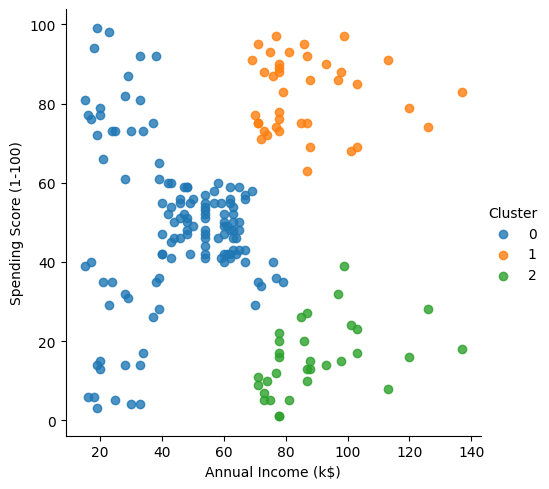

In [13]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True, legend_out=True)